# 3º Entregável — Modelagem de Machine Learning
## Score de risco de motorista a partir de dados de telemetria

**Grupo:**
Arthur Zeferino (RM 570858) · Israel Carneiro de Toledo (RM 573854) · Giovanni Henrique Pereira Hessel (RM 570574) · Suellen Pereira da Silva (RM 573862)

Este notebook dá continuidade à **Sprint 2 (EDA)**, reaproveitando a limpeza e a engenharia de atributos já validadas naquela etapa, e avança para a modelagem propriamente dita: preparação dos dados, treinamento de modelos, validação por holdout, tuning de hiperparâmetros e interpretação das variáveis mais relevantes para o risco.

> Nesta entrega o carregamento é feito diretamente do CSV `TB_MOTORISTA_VEICULO_EVENTO.csv` (o mesmo fallback usado na Sprint 2), eliminando a dependência do RDS/Colab para tornar o notebook reprodutível em qualquer ambiente.

## 0. Setup e recapitulação da Fase 2

As células abaixo reproduzem, de forma resumida, a limpeza e a engenharia de atributos feitas na Sprint 2 (EDA):
- conversão de tipos e criação de `km`, `tempo_horas`;
- contagem de alertas por tipo (`freadas`, `aceleracoes`, `curvas`, `vel_via`) e suas taxas por km;
- filtro de qualidade (`motorista_id` presente, `km >= 10`, `cliente_nome` presente);
- winsorização (P99) das taxas por km;
- `contexto_conducao` (urbano × rodoviário) e o `risco_proxy` (percentil de `alertas_por_km`), que serviu de base para a EDA.

In [1]:
# Imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, classification_report, ConfusionMatrixDisplay,
)

plt.style.use("ggplot")
sns.set_palette("deep")
pd.set_option("display.max_columns", 30)

SEED = 42
np.random.seed(SEED)
MIN_KM = 10

CSV_PATH = "TB_MOTORISTA_VEICULO_EVENTO.csv"  # mesmo arquivo entregue na Sprint 2

In [2]:
# Carregamento (CSV local — sem dependência de RDS/Colab)
df_raw = pd.read_csv(CSV_PATH, sep=";", low_memory=False)
df_raw.columns = [c.strip().lower() for c in df_raw.columns]
print(f"Shape bruto: {df_raw.shape[0]:,} linhas x {df_raw.shape[1]} colunas")
df_raw.head(3)

Shape bruto: 344,681 linhas x 28 colunas


,periodo,motorista_id,veiculo_id,cliente_nome,evento_distancia,evento_tempo_segundos,qtde_eventos,qtde_viagem,velocidade_acima_60_urbano,velocidade_acima_120_rodoviario,qtde_alerta_direcao_acima_velocidade_urbano,qtde_alerta_freada_brusca_urbano,qtde_alerta_aceleracao_brusca_urbano,qtde_velocidade_acima_via_urbano,qtde_velocidade_acima_via_maior_10_percentual_urbano,qtde_velocidade_acima_via_maior_20_percentual_urbano,qtde_velocidade_acima_via_maior_50_percentual_urbano,velocidade_acima_via_percentual_maximo_urbano,velocidade_acima_via_absoluto_maximo_urbano,qtde_alerta_direcao_acima_velocidade_rodoviario,qtde_alerta_freada_brusca_rodoviario,qtde_alerta_aceleracao_brusca_rodoviario,qtde_velocidade_acima_via_rodoviario,qtde_velocidade_acima_via_maior_10_percentual_rodoviario,qtde_velocidade_acima_via_maior_20_percentual_rodoviario,qtde_velocidade_acima_via_maior_50_percentual_rodoviario,velocidade_acima_via_percentual_maximo_rodoviario,velocidade_acima_via_absoluto_maximo_rodoviario
0,2026-01-01 00:00:00 UTC,10455875.0,1254373,CLIENTE 01,196006.142419,42187.0,702,19,701,0,0,0,0,24,13,4,1,76.666667,23.0,0,0,0,0,0,0,0,0.0,0.0
1,2026-01-01 00:00:00 UTC,9825901.0,1190138,CLIENTE 01,141246.844650,19383.0,295,14,245,0,0,0,0,15,2,5,5,123.333333,37.0,0,0,0,0,0,0,0,0.0,0.0
2,2026-01-01 00:00:00 UTC,1961867.0,1337608,CLIENTE 01,123144.118026,6739.0,62,1,15,0,0,0,0,0,0,0,0,0.000000,0.0,0,0,0,12,4,1,1,88.0,44.0


In [3]:
# Limpeza e engenharia de atributos (reprodução da Sprint 2)
df = df_raw.copy()

df["periodo"] = pd.to_datetime(df["periodo"], utc=True, errors="coerce")
for col in ["motorista_id", "veiculo_id", "evento_tempo_segundos"]:
    df[col] = pd.to_numeric(df[col], errors="coerce")
for col in df.select_dtypes(include="number").columns:
    df[col] = pd.to_numeric(df[col], errors="coerce")

df["km"] = df["evento_distancia"] / 1000.0
df["tempo_horas"] = df["evento_tempo_segundos"] / 3600.0

df["freadas"] = df["qtde_alerta_freada_brusca_urbano"].fillna(0) + df["qtde_alerta_freada_brusca_rodoviario"].fillna(0)
df["aceleracoes"] = df["qtde_alerta_aceleracao_brusca_urbano"].fillna(0) + df["qtde_alerta_aceleracao_brusca_rodoviario"].fillna(0)
df["curvas"] = df["qtde_alerta_direcao_acima_velocidade_urbano"].fillna(0) + df["qtde_alerta_direcao_acima_velocidade_rodoviario"].fillna(0)
df["vel_via"] = df["qtde_velocidade_acima_via_urbano"].fillna(0) + df["qtde_velocidade_acima_via_rodoviario"].fillna(0)
df["alertas_total"] = df["freadas"] + df["aceleracoes"] + df["curvas"] + df["vel_via"]

km_safe = df["km"].replace(0, np.nan)
df["alertas_por_km"] = df["alertas_total"] / km_safe
df["viagens_por_km"] = df["qtde_viagem"] / km_safe

# Filtro de qualidade
mask_valid = (
    df["motorista_id"].notna()
    & df["evento_distancia"].notna()
    & (df["km"] >= MIN_KM)
    & df["cliente_nome"].notna()
)
df_clean = df.loc[mask_valid].copy()
print(f"Registros após limpeza: {len(df_clean):,} ({len(df_clean)/len(df):.1%} do bruto)")

# Winsorização P99 da taxa geral de alertas
cap = df_clean["alertas_por_km"].quantile(0.99)
df_clean["alertas_por_km_w"] = df_clean["alertas_por_km"].clip(upper=cap)

# Contexto de condução (urbano x rodoviário)
alertas_urb = (
    df_clean["qtde_alerta_freada_brusca_urbano"] + df_clean["qtde_alerta_aceleracao_brusca_urbano"]
    + df_clean["qtde_alerta_direcao_acima_velocidade_urbano"] + df_clean["qtde_velocidade_acima_via_urbano"]
)
alertas_rod = (
    df_clean["qtde_alerta_freada_brusca_rodoviario"] + df_clean["qtde_alerta_aceleracao_brusca_rodoviario"]
    + df_clean["qtde_alerta_direcao_acima_velocidade_rodoviario"] + df_clean["qtde_velocidade_acima_via_rodoviario"]
)
df_clean["ratio_alertas_rod"] = alertas_rod / (alertas_urb + alertas_rod).replace(0, np.nan)
df_clean["contexto_conducao"] = np.where(
    df_clean["ratio_alertas_rod"] >= 0.5, "rodoviario",
    np.where(df_clean["ratio_alertas_rod"].notna(), "urbano", "indefinido"),
)

# Proxy de risco (percentil de alertas/km) — mesma definição da Sprint 2
df_clean["risco_proxy"] = df_clean["alertas_por_km_w"].rank(pct=True) * 100

df_clean[["km", "alertas_por_km_w", "contexto_conducao", "risco_proxy"]].describe(include="all").T

Registros após limpeza: 288,046 (83.6% do bruto)


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
km,288046.0,NaN,NaN,NaN,1125.753464,1557.471846,10.007878,270.740051,584.114352,1372.075701,180313.135511
alertas_por_km_w,288046.0,NaN,NaN,NaN,0.364905,0.334097,0.0,0.159025,0.261907,0.43657,1.875713
contexto_conducao,288046,3,rodoviario,187903,NaN,NaN,NaN,NaN,NaN,NaN,NaN
risco_proxy,288046.0,NaN,NaN,NaN,50.000174,28.867548,0.197017,25.00026,50.000174,75.000087,99.50008


## 1. Preparação dos dados

### 1.1 Definição do target
A Sprint 2 já indicava, via correlação, que as **taxas de eventos por km** (freada, curva, velocidade na via, aceleração) são as variáveis mais associadas ao `risco_proxy`. Elas são justamente os componentes que somados formam `alertas_por_km` — ou seja, **usá-las como preditoras do próprio `risco_proxy` seria vazamento de dados** (o alvo seria uma função quase determinística das features).

Para a modelagem da Fase 3, portanto:
- o alvo é uma variável categórica de 3 classes — **`categoria_risco`** (`baixo` / `medio` / `alto`) — obtida por tercis do `risco_proxy`, o que garante classes balanceadas;
- as variáveis preditoras usadas são as de **exposição e contexto** (`km`, `tempo_horas`, `qtde_viagem`, `viagens_por_km`, picos de velocidade acima da via, `ratio_alertas_rod`, `contexto_conducao`, `cliente_nome`) — isto é, tudo que **não** entra diretamente na fórmula do proxy de risco.

Isso torna o problema genuinamente preditivo (o modelo precisa aprender um padrão, não recuperar uma soma), o que fica evidente adiante: as métricas de holdout ficam bem abaixo de 100%, ao contrário do que aconteceria se as taxas de alerta por km fossem incluídas como features.

In [4]:
# Target: categoria_risco em tercis do risco_proxy
q1, q2 = df_clean["risco_proxy"].quantile([1/3, 2/3])
df_clean["categoria_risco"] = pd.cut(
    df_clean["risco_proxy"], bins=[-0.01, q1, q2, 100], labels=["baixo", "medio", "alto"]
)

print(f"Cortes de tercil -> baixo <= {q1:.2f} | medio <= {q2:.2f} | alto > {q2:.2f}")
display(df_clean["categoria_risco"].value_counts())

# Remove os poucos registros sem contexto de condução definido (ratio_alertas_rod nulo)
model_df = df_clean.dropna(subset=["ratio_alertas_rod"]).copy()
print(f"\nBase final para modelagem: {len(model_df):,} registros "
      f"({len(df_clean) - len(model_df)} removidos por contexto indefinido)")

Cortes de tercil -> baixo <= 33.33 | medio <= 66.67 | alto > 66.67


categoria_risco
baixo    96016
medio    96015
alto     96015
Name: count, dtype: int64


Base final para modelagem: 286,912 registros (1134 removidos por contexto indefinido)


### 1.2 Seleção de features, split e pré-processamento (scaling + encoding)

- **Numéricas** → `StandardScaler` (necessário sobretudo para KNN e Regressão Logística, sensíveis à escala).
- **Categóricas** (`cliente_nome`, `contexto_conducao`) → `OneHotEncoder`.
- **Holdout**: `train_test_split` 80/20 estratificado pela classe de risco, para preservar a proporção de `baixo` / `medio` / `alto` em treino e teste.

In [5]:
numeric_features = [
    "km", "tempo_horas", "qtde_viagem", "viagens_por_km",
    "velocidade_acima_via_percentual_maximo_urbano",
    "velocidade_acima_via_percentual_maximo_rodoviario",
    "velocidade_acima_via_absoluto_maximo_urbano",
    "velocidade_acima_via_absoluto_maximo_rodoviario",
    "ratio_alertas_rod",
]
categorical_features = ["cliente_nome", "contexto_conducao"]

X = model_df[numeric_features + categorical_features]
y = model_df["categoria_risco"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=SEED, stratify=y
)
print(f"Treino: {X_train.shape} | Teste (holdout): {X_test.shape}")

preprocess = ColumnTransformer([
    ("num", StandardScaler(), numeric_features),
    ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features),
])

Treino: (229529, 11) | Teste (holdout): (57383, 11)


## 2. Treinamento de modelos

Três modelos, cobrindo abordagens distintas:

1. **Regressão Logística** — baseline linear, interpretável via coeficientes.
2. **Random Forest** — não linear, robusto a interações entre variáveis, com `feature_importances_` nativo.
3. **KNN** — modelo baseado em distância, usado também para o tuning básico pedido no enunciado (parâmetro *k*).

Todos são encapsulados em `Pipeline(preprocess + modelo)`, garantindo que o scaling/encoding seja ajustado **apenas no treino** e aplicado de forma consistente no teste.

In [6]:
models = {
    "Regressão Logística": Pipeline([
        ("prep", preprocess),
        ("clf", LogisticRegression(max_iter=1000, random_state=SEED)),
    ]),
    "Random Forest": Pipeline([
        ("prep", preprocess),
        ("clf", RandomForestClassifier(n_estimators=200, random_state=SEED, n_jobs=-1)),
    ]),
    "KNN (k=15)": Pipeline([
        ("prep", preprocess),
        ("clf", KNeighborsClassifier(n_neighbors=15, n_jobs=-1)),
    ]),
}

for name, pipe in models.items():
    pipe.fit(X_train, y_train)
    print(f"[OK] {name} treinado")

[OK] Regressão Logística treinado


[OK] Random Forest treinado


[OK] KNN (k=15) treinado


## 3. Validação (holdout)

Métricas de classificação multiclasse no conjunto de teste (holdout, nunca visto no treino): **accuracy, precision, recall, f1-score (média macro)** e **AUC (One-vs-Rest, média macro)**.

In [7]:
def evaluate(name, pipe, X_test, y_test):
    pred = pipe.predict(X_test)
    proba = pipe.predict_proba(X_test)
    return {
        "modelo": name,
        "accuracy": accuracy_score(y_test, pred),
        "precision_macro": precision_score(y_test, pred, average="macro"),
        "recall_macro": recall_score(y_test, pred, average="macro"),
        "f1_macro": f1_score(y_test, pred, average="macro"),
        "auc_ovr_macro": roc_auc_score(y_test, proba, multi_class="ovr", average="macro"),
    }

resultados = pd.DataFrame([evaluate(n, p, X_test, y_test) for n, p in models.items()]).set_index("modelo")
resultados.round(4)

,accuracy,precision_macro,recall_macro,f1_macro,auc_ovr_macro
modelo,,,,,
Regressão Logística,0.5126,0.4998,0.5132,0.4994,0.6980
Random Forest,0.5670,0.5615,0.5673,0.5637,0.7576
KNN (k=15),0.5372,0.5279,0.5376,0.5305,0.7243


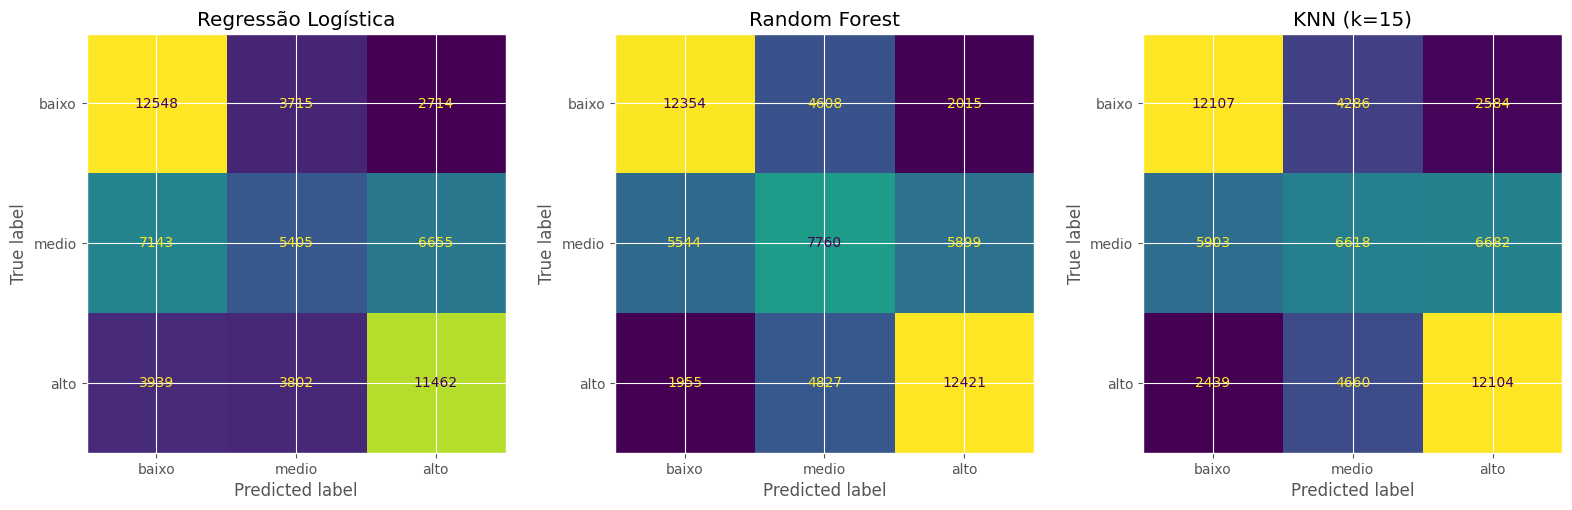

              precision    recall  f1-score   support

        alto       0.61      0.65      0.63     19203
       baixo       0.62      0.65      0.64     18977
       medio       0.45      0.40      0.43     19203

    accuracy                           0.57     57383
   macro avg       0.56      0.57      0.56     57383
weighted avg       0.56      0.57      0.56     57383



In [8]:
# Matriz de confusão dos 3 modelos lado a lado
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for ax, (name, pipe) in zip(axes, models.items()):
    ConfusionMatrixDisplay.from_estimator(
        pipe, X_test, y_test, ax=ax, colorbar=False,
        labels=["baixo", "medio", "alto"],
    )
    ax.set_title(name)
plt.tight_layout()
plt.show()

print(classification_report(y_test, models["Random Forest"].predict(X_test)))

## 4. Tuning básico (k no KNN)

O KNN é o modelo mais sensível a hiperparâmetro nesse conjunto de features. Varremos vários valores de *k* e avaliamos a acurácia no holdout para escolher um valor que equilibre desempenho e custo computacional (k muito baixo → overfitting/ruído; k muito alto → modelo "borra" as fronteiras entre classes).

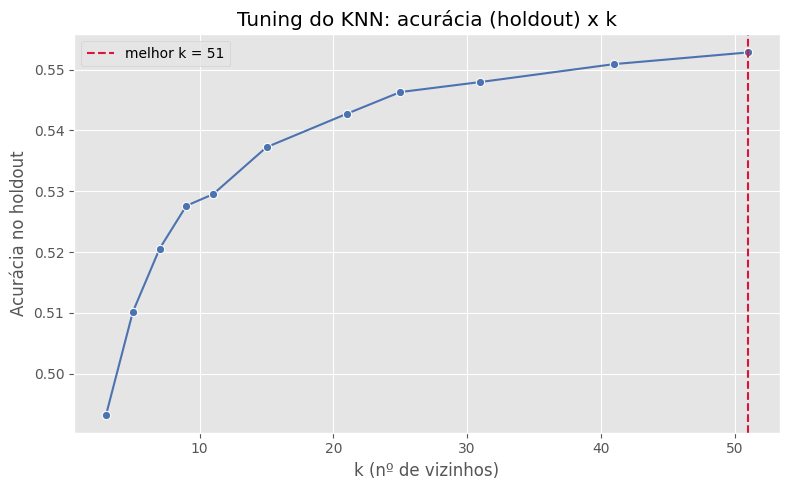

,k,accuracy_holdout
0,3,0.493265
1,5,0.510169
2,7,0.520555
3,9,0.527613
4,11,0.529512
5,15,0.537250
6,21,0.542739
7,25,0.546312
8,31,0.547967
9,41,0.550912


In [9]:
k_values = [3, 5, 7, 9, 11, 15, 21, 25, 31, 41, 51]

# Reaproveita o pré-processamento já ajustado no treino (evita refit repetido do OHE/Scaler)
prep_fitted = models["KNN (k=15)"].named_steps["prep"]
X_train_t = prep_fitted.transform(X_train)
X_test_t = prep_fitted.transform(X_test)

tuning_scores = []
for k in k_values:
    knn_k = KNeighborsClassifier(n_neighbors=k, n_jobs=-1)
    knn_k.fit(X_train_t, y_train)
    acc = accuracy_score(y_test, knn_k.predict(X_test_t))
    tuning_scores.append({"k": k, "accuracy_holdout": acc})

tuning_df = pd.DataFrame(tuning_scores)
best_k = int(tuning_df.loc[tuning_df["accuracy_holdout"].idxmax(), "k"])

plt.figure(figsize=(8, 5))
sns.lineplot(data=tuning_df, x="k", y="accuracy_holdout", marker="o")
plt.axvline(best_k, color="crimson", linestyle="--", label=f"melhor k = {best_k}")
plt.title("Tuning do KNN: acurácia (holdout) x k")
plt.xlabel("k (nº de vizinhos)")
plt.ylabel("Acurácia no holdout")
plt.legend()
plt.tight_layout()
plt.show()

tuning_df

In [10]:
# Modelo final de KNN com o melhor k encontrado
knn_final = Pipeline([
    ("prep", preprocess),
    ("clf", KNeighborsClassifier(n_neighbors=best_k, n_jobs=-1)),
])
knn_final.fit(X_train, y_train)
models["KNN (tunado)"] = knn_final

resultados = pd.concat([
    resultados,
    pd.DataFrame([evaluate("KNN (tunado)", knn_final, X_test, y_test)]).set_index("modelo"),
])
resultados.round(4)

,accuracy,precision_macro,recall_macro,f1_macro,auc_ovr_macro
modelo,,,,,
Regressão Logística,0.5126,0.4998,0.5132,0.4994,0.6980
Random Forest,0.5670,0.5615,0.5673,0.5637,0.7576
KNN (k=15),0.5372,0.5279,0.5376,0.5305,0.7243
KNN (tunado),0.5528,0.5442,0.5532,0.5468,0.7409


## 5. Interpretação — quais variáveis mais impactam o risco?

Duas óticas complementares:
- **Random Forest → `feature_importances_`**: importância média de redução de impureza (captura relações não lineares).
- **Regressão Logística → coeficientes**: magnitude média (valor absoluto) dos coeficientes entre as 3 classes, no espaço padronizado — indica direção e força do efeito linear.

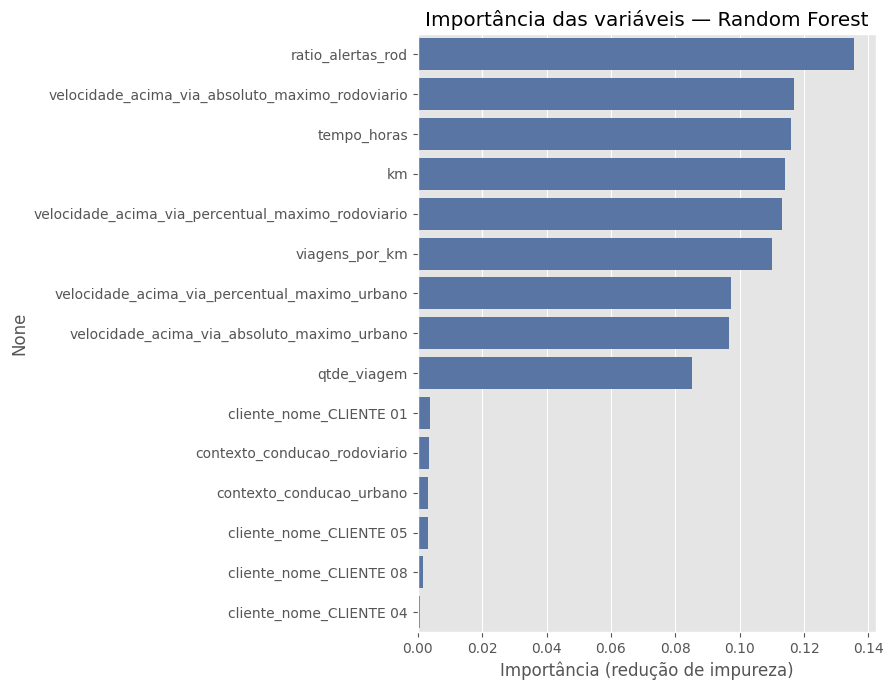

ratio_alertas_rod                                    0.1355
velocidade_acima_via_absoluto_maximo_rodoviario      0.1169
tempo_horas                                          0.1159
km                                                   0.1140
velocidade_acima_via_percentual_maximo_rodoviario    0.1130
viagens_por_km                                       0.1100
velocidade_acima_via_percentual_maximo_urbano        0.0973
velocidade_acima_via_absoluto_maximo_urbano          0.0967
qtde_viagem                                          0.0851
cliente_nome_CLIENTE 01                              0.0038
contexto_conducao_rodoviario                         0.0033
contexto_conducao_urbano                             0.0033
cliente_nome_CLIENTE 05                              0.0030
cliente_nome_CLIENTE 08                              0.0016
cliente_nome_CLIENTE 04                              0.0005
dtype: float64

In [11]:
# Nomes das features após o ColumnTransformer (numéricas + dummies do OHE)
prep_fitted = models["Random Forest"].named_steps["prep"]
ohe = prep_fitted.named_transformers_["cat"]
feature_names = numeric_features + list(ohe.get_feature_names_out(categorical_features))

rf_importances = pd.Series(
    models["Random Forest"].named_steps["clf"].feature_importances_,
    index=feature_names,
).sort_values(ascending=False)

plt.figure(figsize=(9, 7))
sns.barplot(x=rf_importances.values, y=rf_importances.index, orient="h")
plt.title("Importância das variáveis — Random Forest")
plt.xlabel("Importância (redução de impureza)")
plt.tight_layout()
plt.show()

rf_importances.round(4)

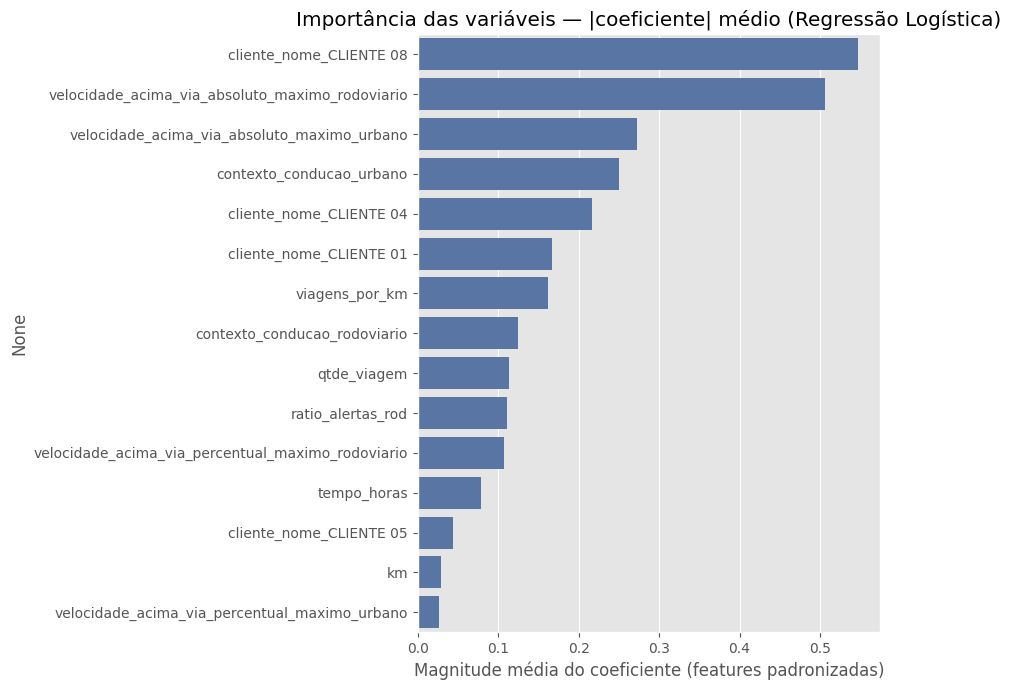

cliente_nome_CLIENTE 08                              0.5472
velocidade_acima_via_absoluto_maximo_rodoviario      0.5059
velocidade_acima_via_absoluto_maximo_urbano          0.2720
contexto_conducao_urbano                             0.2508
cliente_nome_CLIENTE 04                              0.2162
cliente_nome_CLIENTE 01                              0.1663
viagens_por_km                                       0.1619
contexto_conducao_rodoviario                         0.1252
qtde_viagem                                          0.1136
ratio_alertas_rod                                    0.1113
velocidade_acima_via_percentual_maximo_rodoviario    0.1067
tempo_horas                                          0.0782
cliente_nome_CLIENTE 05                              0.0435
km                                                   0.0292
velocidade_acima_via_percentual_maximo_urbano        0.0267
dtype: float64

In [12]:
# Coeficientes da Regressão Logística (magnitude média |coef| entre as classes)
logreg_clf = models["Regressão Logística"].named_steps["clf"]
coef_abs_mean = pd.Series(
    np.abs(logreg_clf.coef_).mean(axis=0), index=feature_names
).sort_values(ascending=False)

plt.figure(figsize=(9, 7))
sns.barplot(x=coef_abs_mean.values, y=coef_abs_mean.index, orient="h")
plt.title("Importância das variáveis — |coeficiente| médio (Regressão Logística)")
plt.xlabel("Magnitude média do coeficiente (features padronizadas)")
plt.tight_layout()
plt.show()

coef_abs_mean.round(4)

### Síntese

* **Random Forest teve o melhor desempenho geral** (accuracy 0,567 / F1-macro 0,564 / AUC 0,758), à frente do KNN tunado (accuracy 0,553 / AUC 0,741) e da Regressão Logística (accuracy 0,513 / AUC 0,698) — esperado, já que a relação entre exposição/contexto e risco tem componentes não lineares que a árvore captura melhor.
* Mesmo excluindo as taxas de alerta por km (para não vazar o alvo), os modelos discriminam risco **claramente acima do acaso** (baseline de 3 classes balanceadas = 33,3%) usando só variáveis de **exposição/contexto** — confirmando o que a Sprint 2 já apontava como "influência moderada".
* **Random Forest** distribui a importância de forma relativamente equilibrada entre `ratio_alertas_rod` (perfil urbano × rodoviário), os picos de velocidade acima da via (absolutos e percentuais, urbano e rodoviário), `tempo_horas`, `km`, `viagens_por_km` e `qtde_viagem` — ou seja, o padrão de exposição (quanto, onde e como o motorista roda) é, como um todo, o que mais discrimina risco nesse modelo.
* Na **Regressão Logística**, chama atenção o peso de `cliente_nome` (em especial `CLIENTE 08`, seguido por `CLIENTE 04` e `CLIENTE 01`) e de `contexto_conducao`, ao lado dos picos de velocidade — sugerindo que, numa relação linear, a frota/política operacional do cliente e o perfil urbano×rodoviário têm um efeito marcante e mais fácil de capturar linearmente do que pela árvore.
* Essa diferença entre os dois modelos ilustra um ponto importante de interpretação: a importância por impureza do Random Forest tende a favorecer variáveis contínuas e de alta frequência, enquanto os coeficientes da Regressão Logística deixam mais evidente o efeito de categorias raras (como `CLIENTE 08`, com poucos registros na base) — por isso vale olhar as duas óticas em conjunto, e não apenas uma.
* **Nota metodológica**: se o objetivo do produto final for justamente "prever alertas_por_km / risco_proxy a partir do comportamento", o pipeline correto não é preditivo e sim descritivo (o proxy É a soma das taxas) — nesse caso, o valor de negócio está em **monitorar diretamente essas taxas**, e não em um modelo preditivo. O modelo preditivo desta seção responde a uma pergunta diferente e mais realista: *"dado o que sei sobre exposição/contexto de um motorista (sem olhar para a contagem de alertas), consigo estimar o nível de risco esperado?"* — útil, por exemplo, para priorizar acompanhamento de motoristas com pouco histórico de telemetria.

## Conclusão

* **Preparação de dados**: reaproveitada da Sprint 2 (limpeza, engenharia de atributos), com `StandardScaler` para numéricas e `OneHotEncoder` para categóricas.
* **Modelos treinados**: Regressão Logística, Random Forest e KNN (baseline e tunado) — 4 configurações no total, superando o mínimo de 2 modelos pedido.
* **Validação**: holdout estratificado 80/20, com accuracy, precision, recall, f1-score e AUC (macro).
* **Tuning**: busca do melhor *k* do KNN por varredura no holdout.
* **Interpretação**: Random Forest e Regressão Logística concordam que `cliente_nome`, os picos de velocidade acima da via e `ratio_alertas_rod` são os sinais mais fortes entre as variáveis de exposição/contexto — com cuidado explícito para não vazar o proxy de risco (que é definido a partir das próprias taxas de alerta) para dentro das features do modelo.

**Próximos passos**: caso surjam labels de risco independentes da telemetria (ex.: sinistros, multas, avaliações do gestor de frota), o problema pode ser remodelado usando as taxas de alerta por km como features "fortes" sem risco de vazamento, o que tende a elevar substancialmente o desempenho preditivo.